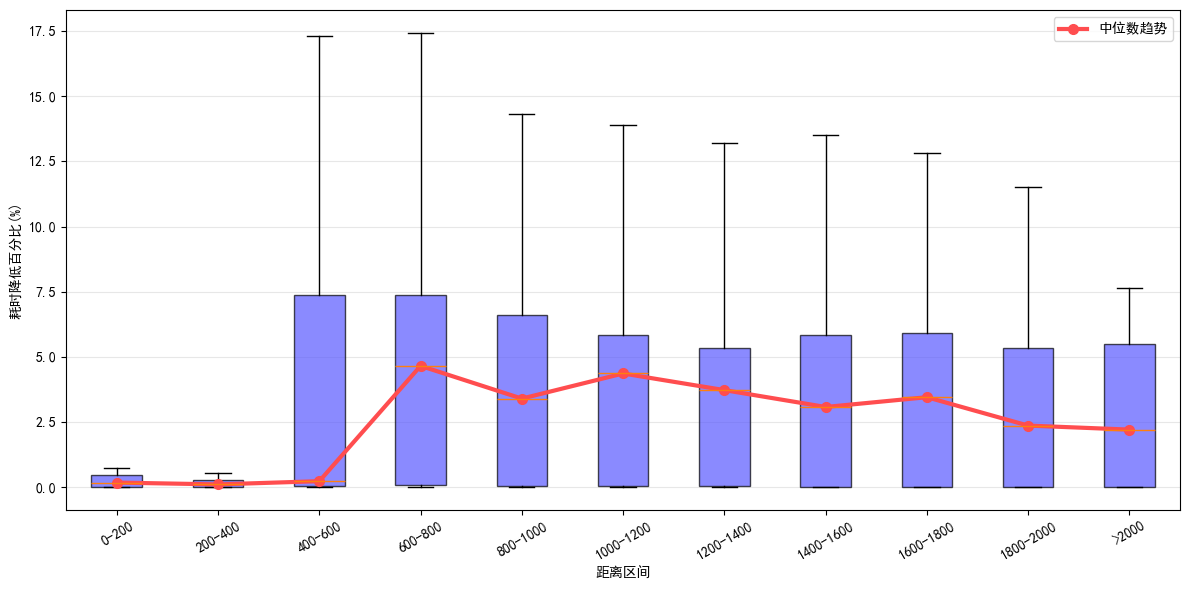

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ====================== 读入两个表 ======================
df_diff = pd.read_excel("差值.xlsx", index_col=0)
df_orig = pd.read_excel("compare_matrix.xlsx", index_col=0)

def parse_id(s):
    nums = re.findall(r'\d+', str(s))
    return int(nums[0]), int(nums[1])

index_ids = df_diff.index.tolist()
col_ids = df_diff.columns.tolist()

dist_list = []
ratio_list = []

# 遍历计算距离 + 耗时降低百分比
for i, start_id in enumerate(index_ids):
    x1, y1 = parse_id(start_id)
    for j, end_id in enumerate(col_ids):
        diff = df_diff.iloc[i, j]
        orig = df_orig.iloc[i, j]

        if pd.isna(diff) or pd.isna(orig) or diff == 0 or orig <= 0:
            continue
        if diff > 0:
            continue

        x2, y2 = parse_id(end_id)
        dx = x2 - x1
        dy = y2 - y1
        dist = np.sqrt(dx**2 + dy**2) * 200

        # 降低百分比转正
        reduce_ratio = -(diff / orig) * 100

        dist_list.append(dist)
        ratio_list.append(reduce_ratio)

df_data = pd.DataFrame({
    "distance": dist_list,
    "reduce_pct": ratio_list
})

# ========== ✅ 去掉等于 0 的数据 ==========
df_data = df_data[df_data["reduce_pct"] != 0]

# ========== 过滤极端值 ==========
df_data = df_data[(df_data["reduce_pct"] >= 0) & (df_data["reduce_pct"] <= 60)]

# ========== 距离分段 ==========
bins = [0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 3000]
labels = ["0-200","200-400","400-600",
          "600-800","800-1000","1000-1200","1200-1400","1400-1600",
          "1600-1800","1800-2000",">2000"]
df_data["dist_bin"] = pd.cut(df_data["distance"], bins=bins, labels=labels)

# ========== 计算每组中位数（用于画折线） ==========
medians = df_data.groupby("dist_bin")["reduce_pct"].median()
x_pos = np.arange(1, len(labels)+1)

# ========== 绘图：箱线图 + 折线 ==========
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 6))

# 画箱线
groups = [df_data[df_data["dist_bin"]==lab]["reduce_pct"].values for lab in labels]
bp = plt.boxplot(groups, patch_artist=True, showfliers=False)

# 箱体颜色
for box in bp["boxes"]:
    box.set_facecolor("#5959FF")
    box.set_alpha(0.7)

# ====================== ✅ 在这里加折线（中位数） ======================
plt.plot(x_pos, medians.values, color="#FF4D4F", linewidth=3, marker='o', markersize=7, label="中位数趋势")

# 坐标轴
plt.xticks(x_pos, labels, rotation=30)
plt.xlabel("距离区间")
plt.ylabel("耗时降低百分比(%)")
# plt.title("不同距离区间耗时降低百分比分布")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np

# ===================== 1. 读取数据 =====================
df1 = pd.read_excel("compare_runtime.xlsx", index_col=0)  # 算法1耗时矩阵
df2 = pd.read_excel("again.xlsx", index_col=0)           # 算法2耗时矩阵

# 确保行列一致
assert df1.shape == df2.shape, "两个表格的行列数不一致，无法对比！"
assert all(df1.index == df2.index) and all(df1.columns == df2.columns), "行列坐标不匹配！"

# ===================== 2. 基础数据准备 =====================
# 展平数据（去掉起点=终点的对角线0值，避免干扰）
mask = ~np.eye(df1.shape[0], dtype=bool)  # 对角线为False，其他为True
time1 = df1.where(mask).values.flatten()
time2 = df2.where(mask).values.flatten()

# 去掉NaN值（对角线部分）
time1 = time1[~np.isnan(time1)]
time2 = time2[~np.isnan(time2)]

# 计算差值（算法2 - 算法1）
diff = time2 - time1

# ===================== 3. 核心对比指标 =====================
print("="*50)
print("📊 两个算法耗时对比统计（已排除起点=终点的0值）")
print("="*50)

print(f"算法1 平均耗时：{np.mean(time1):.6f}")
print(f"算法2 平均耗时：{np.mean(time2):.6f}")
print(f"平均耗时差值（算法2-算法1）：{np.mean(diff):.6f}")
print(f"平均耗时变化率：{(np.mean(time2)/np.mean(time1) - 1)*100:.2f}%")
print("-"*50)

print(f"算法1 中位数耗时：{np.median(time1):.6f}")
print(f"算法2 中位数耗时：{np.median(time2):.6f}")
print("-"*50)

print(f"算法1 最大耗时：{np.max(time1):.6f}")
print(f"算法2 最大耗时：{np.max(time2):.6f}")
print(f"算法1 最小耗时：{np.min(time1):.6f}")
print(f"算法2 最小耗时：{np.min(time2):.6f}")
print("-"*50)

print(f"算法1 耗时标准差：{np.std(time1):.6f}")
print(f"算法2 耗时标准差：{np.std(time2):.6f}")
print("-"*50)

# 谁更快？
count_faster1 = np.sum(diff < 0)  # 算法2比算法1快的次数
count_faster2 = np.sum(diff > 0)  # 算法1比算法2快的次数
count_equal = np.sum(diff == 0)   # 耗时相同的次数
total = len(diff)

print(f"算法2比算法1快的路径数：{count_faster1}（占比{count_faster1/total*100:.2f}%）")
print(f"算法1比算法2快的路径数：{count_faster2}（占比{count_faster2/total*100:.2f}%）")
print(f"耗时完全相同的路径数：{count_equal}（占比{count_equal/total*100:.2f}%）")

print("="*50)

📊 两个算法耗时对比统计（已排除起点=终点的0值）
算法1 平均耗时：0.180137
算法2 平均耗时：0.244433
平均耗时差值（算法2-算法1）：0.064297
平均耗时变化率：35.69%
--------------------------------------------------
算法1 中位数耗时：0.095000
算法2 中位数耗时：0.052000
--------------------------------------------------
算法1 最大耗时：2.870000
算法2 最大耗时：755.580000
算法1 最小耗时：0.000000
算法2 最小耗时：0.000000
--------------------------------------------------
算法1 耗时标准差：0.239787
算法2 耗时标准差：3.964964
--------------------------------------------------
算法2比算法1快的路径数：26804（占比70.85%）
算法1比算法2快的路径数：10635（占比28.11%）
耗时完全相同的路径数：391（占比1.03%）
